In [2]:

import os
import json
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [3]:
DATASET_NAME = 'CIFAR10'
DATA_ROOT = './data'
BATCH_SIZE = 128
VAL_RATIO = 0.2

# Трансформации для CIFAR10 (3 канала RGB)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # RGB нормализация
])

train_dataset_full = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=transform)
num_classes = 10

# Разбиение train/val с фиксированным seed
n_train = len(train_dataset_full)
indices = torch.randperm(n_train, generator=torch.Generator().manual_seed(SEED)).tolist()
n_val = int(n_train * VAL_RATIO)

train_indices = indices[n_val:]
val_indices = indices[:n_val]

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(train_dataset_full, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataset: {DATASET_NAME}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Classes: {num_classes}")

# Sanity check
x_batch, y_batch = next(iter(train_loader))
print(f"Batch: x={x_batch.shape}, y={y_batch.shape}")
print(f"Range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]



Dataset: CIFAR10
Train: 40000, Val: 10000, Test: 10000
Classes: 10
Batch: x=torch.Size([128, 3, 32, 32]), y=torch.Size([128])
Range: [-1.000, 1.000]


In [4]:

class MLP(nn.Module):
    """MLP для CIFAR10: вход 32×32×3 = 3072"""

    def __init__(self, input_size, hidden_sizes, num_classes,
                 dropout_rate=0.0, use_batchnorm=False):
        super(MLP, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten: [B, 3, 32, 32] → [B, 3072]
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.network(x)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    return total_loss / total, 100.0 * correct / total


def train_with_early_stopping(model, train_loader, val_loader, optimizer,
                               criterion, device, max_epochs, patience=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_model_state = 0.0, None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return history, epoch + 1, best_val_acc


def train_normal(model, train_loader, val_loader, optimizer, criterion, device, epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_model_state = 0.0, None

    for epoch in range(epochs):
        print("EPOCH:", epoch)
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = deepcopy(model.state_dict())

    if best_model_state:
        model.load_state_dict(best_model_state)

    return history, epochs, best_val_acc

In [5]:

ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Параметры для CIFAR10
INPUT_SIZE = 32 * 32 * 3  # 3072 для RGB 32x32
HIDDEN_SIZES = [512, 256, 128]  # MLP для демонстрации
BASE_EPOCHS = 15  # Меньше эпох т.к. CIFAR10 сложнее
BASE_LR = 1e-3

all_results = []


In [6]:
print("\n[E1] Base (no Dropout, no BatchNorm)")
model_e1 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, 0.0, False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=BASE_LR)
criterion = nn.CrossEntropyLoss()
history_e1, epochs_e1, best_val_acc_e1 = train_normal(model_e1, train_loader, val_loader, optimizer_e1, criterion, device, BASE_EPOCHS)

all_results.append({
    'experiment_id': 'E1', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout=0.0, batchnorm=False',
    'optimizer': 'Adam', 'lr': BASE_LR, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': epochs_e1, 'best_val_accuracy': best_val_acc_e1, 'best_val_loss': min(history_e1['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_e1:.2f}%")


print("\n[E2] Dropout (p=0.3)")
DROPOUT_RATE = 0.3
model_e2 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, DROPOUT_RATE, False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=BASE_LR)
history_e2, epochs_e2, best_val_acc_e2 = train_normal(model_e2, train_loader, val_loader, optimizer_e2, criterion, device, BASE_EPOCHS)

all_results.append({
    'experiment_id': 'E2', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={DROPOUT_RATE}, batchnorm=False',
    'optimizer': 'Adam', 'lr': BASE_LR, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': epochs_e2, 'best_val_accuracy': best_val_acc_e2, 'best_val_loss': min(history_e2['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_e2:.2f}%")


print("\n[E3] BatchNorm")
model_e3 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, 0.0, True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=BASE_LR)
history_e3, epochs_e3, best_val_acc_e3 = train_normal(model_e3, train_loader, val_loader, optimizer_e3, criterion, device, BASE_EPOCHS)

all_results.append({
    'experiment_id': 'E3', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout=0.0, batchnorm=True',
    'optimizer': 'Adam', 'lr': BASE_LR, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': epochs_e3, 'best_val_accuracy': best_val_acc_e3, 'best_val_loss': min(history_e3['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_e3:.2f}%")

print("\n[E4] EarlyStopping (лучший из E2/E3)")

if best_val_acc_e2 >= best_val_acc_e3:
    best_config = {'dropout': DROPOUT_RATE, 'batchnorm': False}
    print(f"Выбран E2 (Dropout): {best_val_acc_e2:.2f}%")
else:
    best_config = {'dropout': 0.0, 'batchnorm': True}
    print(f"Выбран E3 (BatchNorm): {best_val_acc_e3:.2f}%")

model_e4 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, best_config['dropout'], best_config['batchnorm']).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=BASE_LR)
history_e4, epochs_e4, best_val_acc_e4 = train_with_early_stopping(model_e4, train_loader, val_loader, optimizer_e4, criterion, device, 40, patience=5)

all_results.append({
    'experiment_id': 'E4', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={best_config["dropout"]}, batchnorm={best_config["batchnorm"]}, early_stopping=True',
    'optimizer': 'Adam', 'lr': BASE_LR, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': epochs_e4, 'best_val_accuracy': best_val_acc_e4, 'best_val_loss': min(history_e4['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_e4:.2f}%, Epochs: {epochs_e4}")

# Сохранение лучшей модели
torch.save(model_e4.state_dict(), ARTIFACTS_DIR / 'best_model.pt')

best_model_config = {
    'dataset': DATASET_NAME, 'seed': SEED, 'input_size': INPUT_SIZE,
    'hidden_sizes': HIDDEN_SIZES, 'num_classes': num_classes,
    'dropout': best_config['dropout'], 'batchnorm': best_config['batchnorm'],
    'optimizer': 'Adam', 'lr': BASE_LR, 'batch_size': BATCH_SIZE,
    'early_stopping_patience': 5, 'best_val_accuracy': best_val_acc_e4, 'epochs_trained': epochs_e4
}
with open(ARTIFACTS_DIR / 'best_config.json', 'w') as f:
    json.dump(best_model_config, f, indent=2)


print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST")
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


[E1] Base (no Dropout, no BatchNorm)
EPOCH: 0
EPOCH: 1
EPOCH: 2
EPOCH: 3
EPOCH: 4
EPOCH: 5
EPOCH: 6
EPOCH: 7
EPOCH: 8
EPOCH: 9
EPOCH: 10
EPOCH: 11
EPOCH: 12
EPOCH: 13
EPOCH: 14
Val Accuracy: 54.11%

[E2] Dropout (p=0.3)
EPOCH: 0
EPOCH: 1
EPOCH: 2
EPOCH: 3
EPOCH: 4
EPOCH: 5
EPOCH: 6
EPOCH: 7
EPOCH: 8
EPOCH: 9
EPOCH: 10
EPOCH: 11
EPOCH: 12
EPOCH: 13
EPOCH: 14
Val Accuracy: 54.56%

[E3] BatchNorm
EPOCH: 0
EPOCH: 1
EPOCH: 2
EPOCH: 3
EPOCH: 4
EPOCH: 5
EPOCH: 6
EPOCH: 7
EPOCH: 8
EPOCH: 9
EPOCH: 10
EPOCH: 11
EPOCH: 12
EPOCH: 13
EPOCH: 14
Val Accuracy: 54.82%

[E4] EarlyStopping (лучший из E2/E3)
Выбран E3 (BatchNorm): 54.82%
Early stopping at epoch 16
Val Accuracy: 55.25%, Epochs: 16
ФИНАЛЬНАЯ ОЦЕНКА НА TEST
Test Accuracy: 55.15%
Test Loss: 1.4584


In [7]:


FIXED_DROPOUT = best_config['dropout']
FIXED_BATCHNORM = best_config['batchnorm']

# O1: LR слишком большой
print("\n[O1] LR слишком большой (1e-1)")
model_o1 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, FIXED_DROPOUT, FIXED_BATCHNORM).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)
history_o1, epochs_o1, best_val_acc_o1 = train_normal(model_o1, train_loader, val_loader, optimizer_o1, criterion, device, 8)

all_results.append({
    'experiment_id': 'O1', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={FIXED_DROPOUT}, batchnorm={FIXED_BATCHNORM}',
    'optimizer': 'Adam', 'lr': 1e-1, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': epochs_o1, 'best_val_accuracy': best_val_acc_o1, 'best_val_loss': min(history_o1['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_o1:.2f}%")

# O2: LR слишком маленький
print("\n[O2] LR слишком маленький (1e-5)")
model_o2 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, FIXED_DROPOUT, FIXED_BATCHNORM).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
history_o2, epochs_o2, best_val_acc_o2 = train_normal(model_o2, train_loader, val_loader, optimizer_o2, criterion, device, 8)

all_results.append({
    'experiment_id': 'O2', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={FIXED_DROPOUT}, batchnorm={FIXED_BATCHNORM}',
    'optimizer': 'Adam', 'lr': 1e-5, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': epochs_o2, 'best_val_accuracy': best_val_acc_o2, 'best_val_loss': min(history_o2['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_o2:.2f}%")

# O3: SGD + momentum + weight decay
print("\n[O3] SGD + momentum + weight decay")
model_o3 = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes, FIXED_DROPOUT, FIXED_BATCHNORM).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
history_o3, epochs_o3, best_val_acc_o3 = train_normal(model_o3, train_loader, val_loader, optimizer_o3, criterion, device, 15)

all_results.append({
    'experiment_id': 'O3', 'dataset': DATASET_NAME, 'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={FIXED_DROPOUT}, batchnorm={FIXED_BATCHNORM}',
    'optimizer': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4,
    'epochs_trained': epochs_o3, 'best_val_accuracy': best_val_acc_o3, 'best_val_loss': min(history_o3['val_loss'])
})
print(f"Val Accuracy: {best_val_acc_o3:.2f}%")



[O1] LR слишком большой (1e-1)
EPOCH: 0
EPOCH: 1
EPOCH: 2
EPOCH: 3
EPOCH: 4
EPOCH: 5
EPOCH: 6
EPOCH: 7
Val Accuracy: 50.82%

[O2] LR слишком маленький (1e-5)
EPOCH: 0
EPOCH: 1
EPOCH: 2
EPOCH: 3
EPOCH: 4
EPOCH: 5
EPOCH: 6
EPOCH: 7
Val Accuracy: 48.92%

[O3] SGD + momentum + weight decay
EPOCH: 0
EPOCH: 1
EPOCH: 2
EPOCH: 3
EPOCH: 4
EPOCH: 5
EPOCH: 6
EPOCH: 7
EPOCH: 8
EPOCH: 9
EPOCH: 10
EPOCH: 11
EPOCH: 12
EPOCH: 13
EPOCH: 14
Val Accuracy: 54.64%


Saved: artifacts/runs.csv


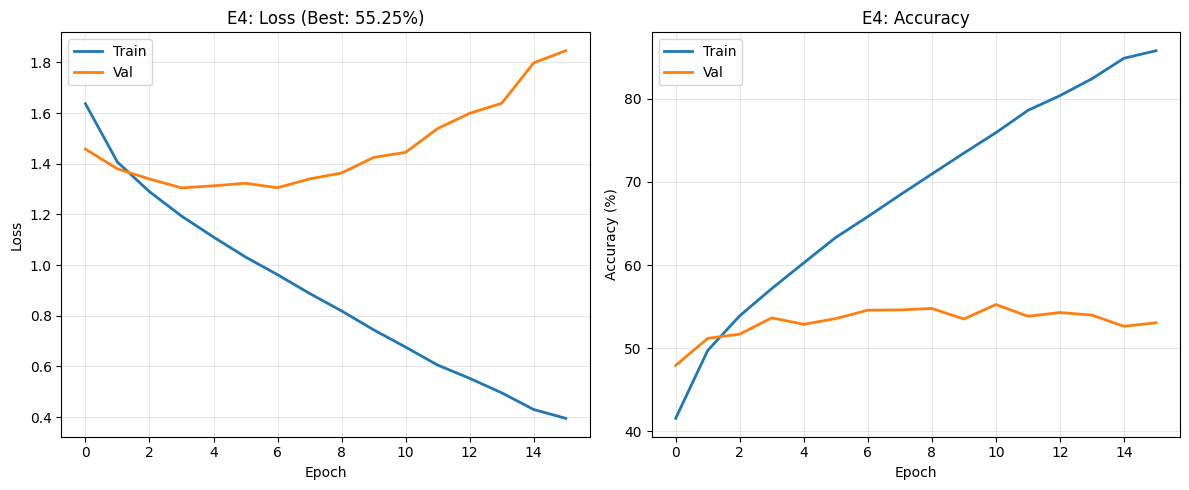

Saved: artifacts/figures/curves_best.png


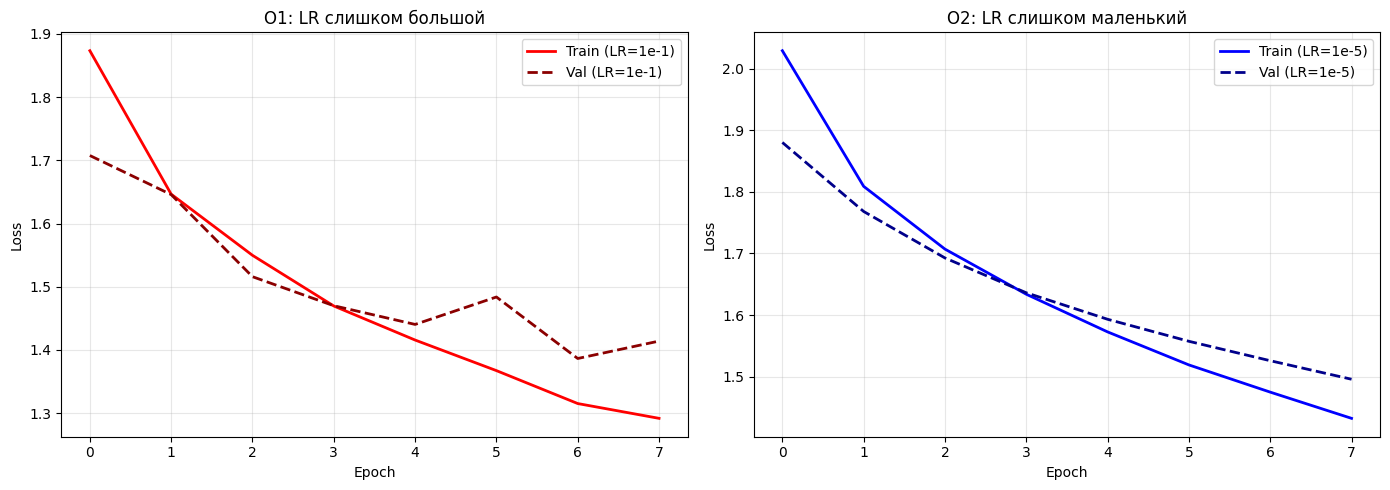

Saved: artifacts/figures/curves_lr_extremes.png

СВОДНАЯ ТАБЛИЦА
Exp    Opt    LR         WD         Epochs   Val Acc   
------------------------------------------------------------
E1     Adam   1e-03      0e+00      15       54.11     
E2     Adam   1e-03      0e+00      15       54.56     
E3     Adam   1e-03      0e+00      15       54.82     
E4     Adam   1e-03      0e+00      16       55.25     
O1     Adam   1e-01      0e+00      8        50.82     
O2     Adam   1e-05      0e+00      8        48.92     
O3     SGD    1e-02      1e-04      15       54.64     


In [8]:
with open(ARTIFACTS_DIR / 'runs.csv', 'w', newline='') as f:
    fieldnames = ['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr', 'momentum', 'weight_decay', 'epochs_trained', 'best_val_accuracy', 'best_val_loss']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_results)
print(f"Saved: {ARTIFACTS_DIR / 'runs.csv'}")

# %%
# Графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_e4['train_loss'], label='Train', linewidth=2)
plt.plot(history_e4['val_loss'], label='Val', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'E4: Loss (Best: {best_val_acc_e4:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_e4['train_acc'], label='Train', linewidth=2)
plt.plot(history_e4['val_acc'], label='Val', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('E4: Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'curves_best.png'}")

# %%
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_o1['train_loss'], label='Train (LR=1e-1)', linewidth=2, color='red')
plt.plot(history_o1['val_loss'], label='Val (LR=1e-1)', linewidth=2, color='darkred', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('O1: LR слишком большой')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_o2['train_loss'], label='Train (LR=1e-5)', linewidth=2, color='blue')
plt.plot(history_o2['val_loss'], label='Val (LR=1e-5)', linewidth=2, color='darkblue', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('O2: LR слишком маленький')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'curves_lr_extremes.png'}")

# %%
# Сводная таблица
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА")
print("=" * 60)
print(f"{'Exp':<6} {'Opt':<6} {'LR':<10} {'WD':<10} {'Epochs':<8} {'Val Acc':<10}")
print("-" * 60)
for r in all_results:
    print(f"{r['experiment_id']:<6} {r['optimizer']:<6} {r['lr']:<10.0e} {r['weight_decay']:<10.0e} {r['epochs_trained']:<8} {r['best_val_accuracy']:<10.2f}")
